# LSE ST451: Bayesian Machine Learning
## Author: Kostas Kalogeropoulos

## Week 5: Variational Bayes

Topics covered 
 - Mean field approximation
 - Automatic Differentiation Variational Inference (ADVI) in PyMC

In [1]:
import pandas as pd
import numpy as np

### Mean Field approximation 

We will first simulate $100$ independent observations from the model 

$$
y\sim N(\mu, \tau^{-1})
$$

with $\mu=5$ and $\tau^{-1}=0.5$.

Then we will treat $\mu$ and $\tau^{-1}$ as unknown and will use the mean field approximation algorithm presented in the lecture to estimated them. 

#### Simulate Data

In [2]:
#Set parameters and simulate data
n = 100
mu = 3
tau = 2
std = np.sqrt(1/tau)
y = mu + std*np.random.randn(n)

#Set prior hyperparameters
mu0 = 0
lam0 = 1 #unit information prior
a0 = 0.001
b0 = 0.001


# get sufficient stats
Sy = np.sum(y)
Sy2 = np.sum(y**2)
m02 = mu0**2

#### Run the algorithm

In [ ]:
#initialise parameters
muf = 0
tauf = 1
af = 1
bf = 1

#algorithmic parameters
maxiter = 1000
tol = 0.0000001

#objects to store the values of the parameters to be optimised.
Thetas = np.ones((maxiter,4))
Thetas[0,] = np.array([muf,tauf,af,bf])

#main while loop
i = 0
diff = 1 
while (i<maxiter) and (diff>tol):
    i = i+1
    af = a0+(n+1)/2
    Emu = muf   #E(mu)
    Emu2 = (1/tauf)+muf**2   #E(mu^2)
    bf = b0+0.5*(Sy2-2*muf*Sy+n*Emu2)+0.5*lam0*(m02 - 2*muf*mu0 + Emu2)
    tauf = (lam0+n)*af/bf   #E(tau)
    muf = (lam0*mu0+Sy)/(lam0+n)
    Thetas[i,] = np.array([muf,tauf,af,bf])
    dThetas = (Thetas[i,]-Thetas[i-1,])**2
    diff = np.max(dThetas)
    print(Thetas[i,])

#summarise output
muf = Thetas[i,0]
tauf = Thetas[i,1]
af = Thetas[i,2]
bf = Thetas[i,3]
print('Converged at ',i,' iterations')
results = np.array([[muf,af/bf,tauf],[np.mean(y),1/np.var(y),n/np.var(y)]])
col = ['muf','tauf','tau muf']
ind = ['VB','MLE']
results = pd.DataFrame(results,columns = col,index=ind)
results

[  2.90023435  10.03448989  50.501      508.30695511]
[  2.90023435 133.99377774  50.501       38.06595415]
[  2.90023435 152.66600578  50.501       33.41019485]
[  2.90023435 152.87692856  50.501       33.36409914]
[  2.90023435 152.87901978  50.501       33.36364275]
[  2.90023435 152.87904048  50.501       33.36363823]
Converged at  6  iterations


,muf,tauf,tau muf
VB,2.900234,1.513654,152.879040
MLE,2.929237,1.737041,173.704144


### Activity 1

Let $y=(y_1, \dots, y_n)$ be independent Poisson($\lambda$) observations. Assume that $\lambda$ follows the Gamma($2,\beta$) distribution, where $\beta$ follows the Exponential($1$) distribution. The aim is to draw inference from the posterior $\pi(\theta|y)$, where $\theta=(\lambda, \beta)$. 

#### Simulate data

In [5]:
#Set parameters and simulate data
n = 100
np.random.seed(1)
beta_true = np.random.exponential(1,1)
lambda_true  = np.random.gamma(2,1/beta_true,1)
print('beta value: ',beta_true,' lambda value: ',lambda_true)
y = np.random.poisson(lambda_true,n)

# get sufficient stats
sy = np.sum(y)
print('ybar: ',sy/n)

beta value:  [0.53960584]  lambda value:  [1.53955169]
ybar:  1.41


The variational Bayes algorithm **approximates** $\pi(\theta|y)$ using the mean field approximation 

$$
q(\theta|y, \phi)=q(\lambda|y, \phi)q(\beta|y, \phi)
$$

It can be shown (see exam paper of 2019, question 2a) that such an algorithm may consist of the following steps

 1. Initialise at $q(\lambda)$ to be the Gamma($a_{\lambda},b_{\lambda}$) and $q(\beta)$ to be the Gamma($a_{\beta},b_{\beta}$) distribution, setting $$a_{\lambda}=2+\sum_iy_i,\;\; b_{\lambda}=b_{\lambda}^0,\;\;\;a_{\beta}=3,\;\text{ and }\;\;b_{\beta}=b_{\beta}^0. $$
 2. Iteratively update $b_{\lambda}$ and $b_{\beta}$ until the parameters or the ELBO converge. At iteration $i$ will have:
 
    a. Set $$b_{\lambda}^{i}=n+\mathbb{E}_{q(\beta)}[\beta]=n+3/b_{\beta}^{i-1}$$
    
    b. Set $$b_{\beta}^{i}=1+\mathbb{E}_{q(\lambda)}[\lambda]=1+(2+\sum_iy_i)/b_{\lambda}^{i}$$


**Task:** Code the above algorithm and fit it to the simulated data. Check your answers in terms of the lambda estimates.

Put your code below

In [6]:
#initialise parameters
a_lam = 2+np.sum(y)
b_lam = 1 # this was set to an arbitrary value. feel free to try another one
a_bet = 3
b_bet = 0.001 # this was set to an arbitrary value. feel free to try another one

#algorithmic parameters
maxiter = 1000
tol = 0.0000001

#objects to store the values of the parameters to be optimised.
Thetas = np.ones((maxiter,4))
Thetas[0,] = np.array([a_lam,b_lam,a_bet,b_bet])

#main while loop
i = 0
diff = 1 
while (i<maxiter) and (diff>tol):
    i = i+1
    b_lam = n + (3/b_bet)
    b_bet = 1 + ((2+sy)/b_lam)
    Thetas[i,] = np.array([a_lam,b_lam,a_bet,b_bet])
    dThetas = (Thetas[i,]-Thetas[i-1,])**2
    diff = np.max(dThetas)

#summarise output
a_lam = Thetas[i,0]
b_lam = Thetas[i,1]
a_bet = Thetas[i,2]
b_bet = Thetas[i,3]
print('Converged at ',i,' iterations')

print('lambda VB mean: ',a_lam/b_lam, 'lambda MLE: ',sy/n,' true lambda ',lambda_true)

print('beta VB mean: ',a_bet/b_bet, ' true beta ',beta_true)

# Check VB for beta
beta_samples = np.random.gamma(a_bet,1/b_bet,100000)
np.percentile(beta_samples,99.5)
print('beta VB 95% credible interval: ',np.percentile(beta_samples,2.5),np.percentile(beta_samples,97.5) )

Converged at  5  iterations
lambda VB mean:  1.4124355569274771 lambda MLE:  1.41  true lambda  [1.53955169]
beta VB mean:  1.2435565341363382  true beta  [0.53960584]
beta VB 95% credible interval:  0.257226438146231 2.9981648737205036


### Automatic Differentiation Variational Inference (ADVI) with PyMC

To use `PyMC` it is recommended to install it in a conda environment. To do so execute the following steps.

- Open a command window and type the following to install `PyMC` to the conda environment `pymc_env`:\
  `conda create -c conda-forge -n pymc_env "pymc>=5"`
- Then activate the `pymc_env` by typing:\
  `conda activate pymc_env`
- If you want to use PyMC from a Jupyter notebook you will also need to install `ipykernel`:\
  `conda install -c anaconda ipykernel`
- Also run this line to add `pymc_env` in the list of kernels in a Jupyter notebook:\
  `python -m ipykernel install --user --name=pymc_env`
- Some packages, e.g. scikit learn may need to be re-installed in this environment (`numpy`, `pandas`, `matplotlib` work fine though). You can do this by typing:\
  `pip install -U scikit-learn`

#### Demonstration in linear regression

In [8]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy.special import expit

ModuleNotFoundError: No module named 'arviz'

### Data-generating process (simulation)

Let $n=100$. For each observation $i=1,\dots,n$,

$$
X_{1i} \sim \mathcal{N}(0,1), 
\qquad 
X_{2i} \sim \mathcal{N}\!\left(0, 0.2^2\right).
$$

The code uses the true parameter values
$$
\alpha_{\text{true}} = 1, 
\qquad 
\beta_{\text{true}} = (\beta_{1,\text{true}},\beta_{2,\text{true}})=(1,\,2.5),
\qquad
\sigma_{\text{true}} = 1.
$$

The outcome is generated by
$$
Y_i = \alpha_{\text{true}} + \beta_{1,\text{true}} X_{1i} + \beta_{2,\text{true}} X_{2i} + \varepsilon_i,
\qquad 
\varepsilon_i \sim \mathcal{N}(0,\sigma_{\text{true}}^2).
$$

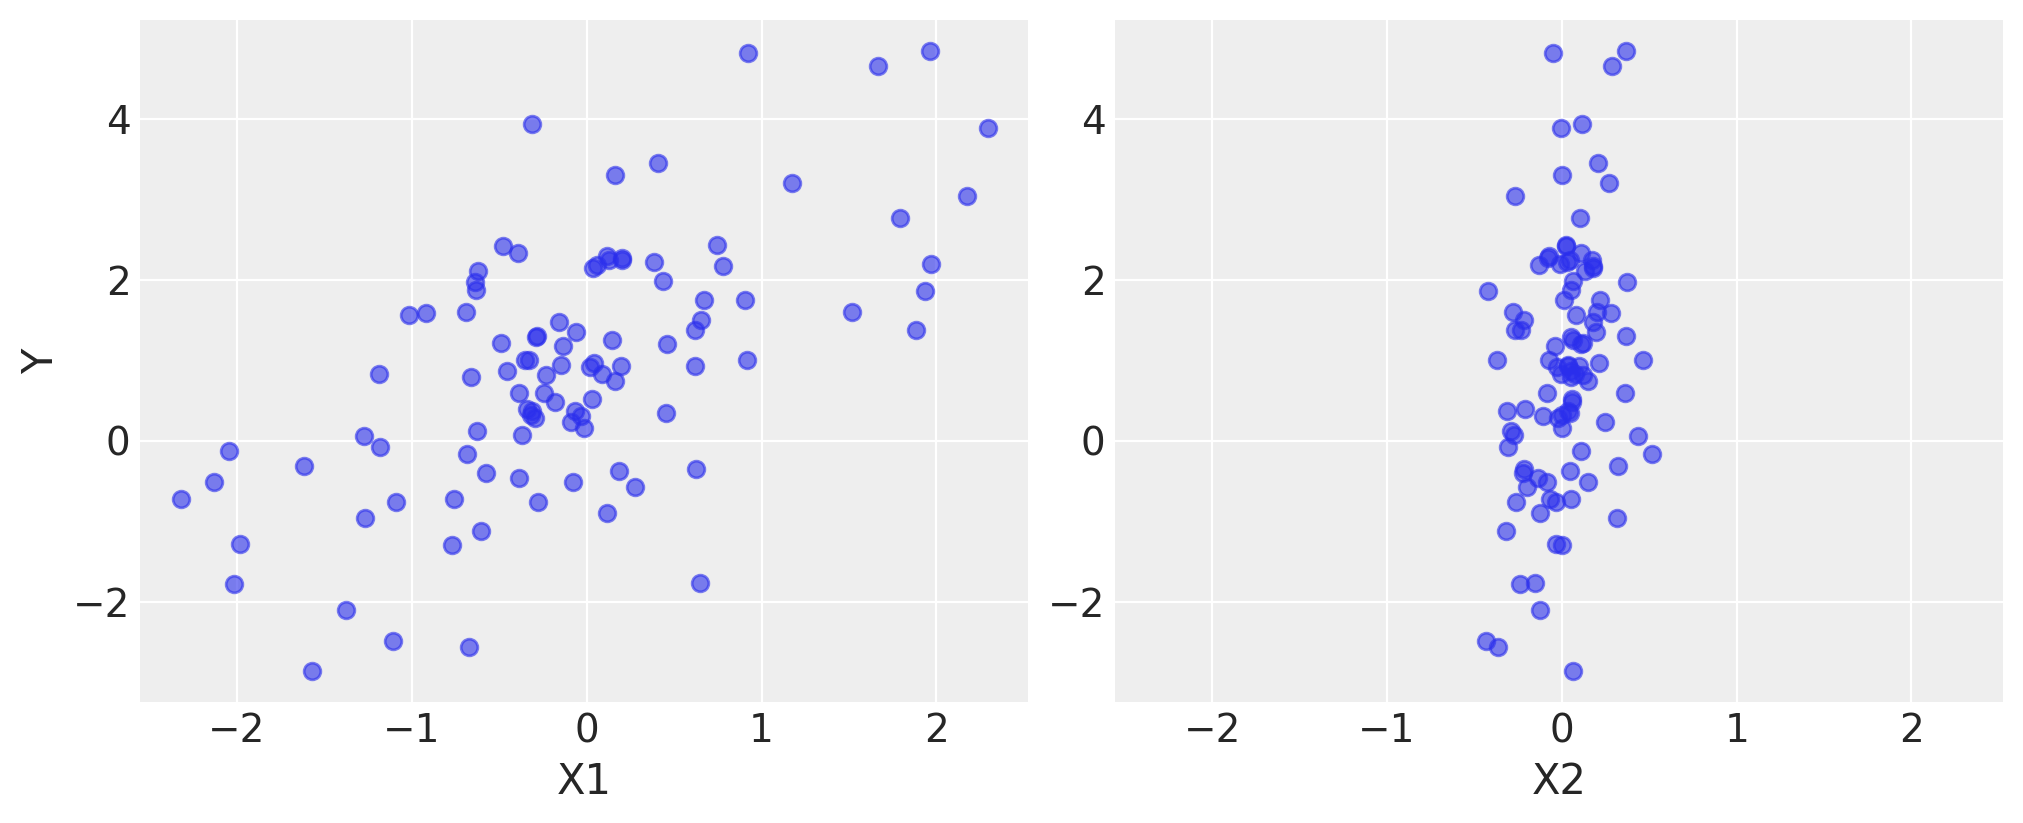

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")

# True parameter values
alpha, sigma = 1, 1
beta = [1, 2.5]

# Size of dataset
size = 100

# Predictor variable
X1 = np.random.randn(size)
X2 = np.random.randn(size) * 0.2

# Simulate outcome variable
Y = alpha + beta[0] * X1 + beta[1] * X2 + np.random.randn(size) * sigma

fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 4))
axes[0].scatter(X1, Y, alpha=0.6)
axes[1].scatter(X2, Y, alpha=0.6)
axes[0].set_ylabel("Y")
axes[0].set_xlabel("X1")
axes[1].set_xlabel("X2");

---

### Bayesian linear regression model (PyMC)
Equivalently, conditional on parameters and predictors,
$$
Y_i \mid \alpha,\beta_1,\beta_2,\sigma,X_{1i},X_{2i}
\sim
\mathcal{N}\!\left(\alpha+\beta_1 X_{1i}+\beta_2 X_{2i},\ \sigma^2\right).
$$

Let $\theta=(\alpha,\beta_1,\beta_2,\sigma)$.

#### Priors
$$
\alpha \sim \mathcal{N}(0,10^2),
$$
$$
\beta_j \sim \mathcal{N}(0,10^2), \quad j=1,2 \quad (\text{independent}),
$$
$$
\sigma \sim \text{HalfNormal}(1),
\quad\text{i.e. } \sigma>0,\ \ p(\sigma)\propto \exp\!\left(-\frac{\sigma^2}{2}\right).
$$

#### Likelihood
For $i=1,\dots,n$,
$$
Y_i \mid \alpha,\beta_1,\beta_2,\sigma, X_{1i},X_{2i}
\sim
\mathcal{N}(\mu_i,\sigma^2),
\qquad
\mu_i=\alpha+\beta_1 X_{1i}+\beta_2 X_{2i}.
$$

In [3]:
basic_model = pm.Model()

with basic_model:

    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

## Mean-field ADVI formulation for the Bayesian linear regression

Let the model be
$$
y_i \mid \alpha,\beta_1,\beta_2,\sigma \sim \mathcal{N}(\mu_i,\sigma^2),
\qquad 
\mu_i = \alpha + \beta_1 x_{1i} + \beta_2 x_{2i},
\quad i=1,\dots,n,
$$
with priors
$$
\alpha \sim \mathcal{N}(0,10^2), \qquad
\beta_j \sim \mathcal{N}(0,10^2)\ (j=1,2), \qquad
\sigma \sim \mathrm{HalfNormal}(1).
$$

### 1) Transform to an unconstrained space

Collect parameters as $\theta=(\alpha,\beta_1,\beta_2,\sigma)\in\Theta$.
Define an invertible transform $T:\Theta\to\mathbb{R}^4$ by
$$
\zeta = T(\theta) = (\zeta_\alpha,\zeta_{\beta_1},\zeta_{\beta_2},\zeta_\sigma)
= (\alpha,\beta_1,\beta_2,\log\sigma).
$$
Hence the inverse transform is
$$
\theta = T^{-1}(\zeta) = (\alpha,\beta_1,\beta_2,\exp(\zeta_\sigma)).
$$

The joint density in $\zeta$-space includes the Jacobian term:
$$
\log p(y,\zeta)
=
\log p\!\left(y, T^{-1}(\zeta)\right)
+
\log\left|\det J_{T^{-1}}(\zeta)\right|.
$$
(Here $\log|\det J_{T^{-1}}(\zeta)| = \zeta_\sigma$ since $\sigma=\exp(\zeta_\sigma)$.)

### 2) Mean-field variational family (ADVI default)

Mean-field ADVI posits a fully factorized Gaussian approximation in $\mathbb{R}^4$:
$$
q(\zeta\mid\phi)=\prod_{j=1}^{4}\mathcal{N}(\zeta_j\mid m_j,s_j^2),
\qquad
\phi=(m_1,\dots,m_4,s_1,\dots,s_4).
$$

### 3) Induced approximation in the original parameter space

The corresponding variational approximation for $\theta$ is induced by the transform:
$$
q(\theta\mid\phi)
=
q(T(\theta)\mid\phi)\,\left|\det J_T(\theta)\right|.
$$
In particular, even though $q(\zeta\mid\phi)$ is Gaussian, the implied $q(\sigma\mid\phi)$
is log-normal (due to $\sigma=\exp(\zeta_\sigma)$).

### 4) Optimisation objective (ELBO)

ADVI fits $\phi$ by maximising the ELBO:
$$
\mathrm{ELBO}(\phi)
=
\mathbb{E}_{q(\zeta\mid\phi)}
\Big[
\log p\!\left(y, T^{-1}(\zeta)\right)
+
\log\left|\det J_{T^{-1}}(\zeta)\right|
-
\log q(\zeta\mid\phi)
\Big].
$$

In [4]:
with basic_model:
    mean_field = pm.fit() # mean-field ADVI

C:\Users\13287\anaconda3\envs\gpflow310\lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 164.24


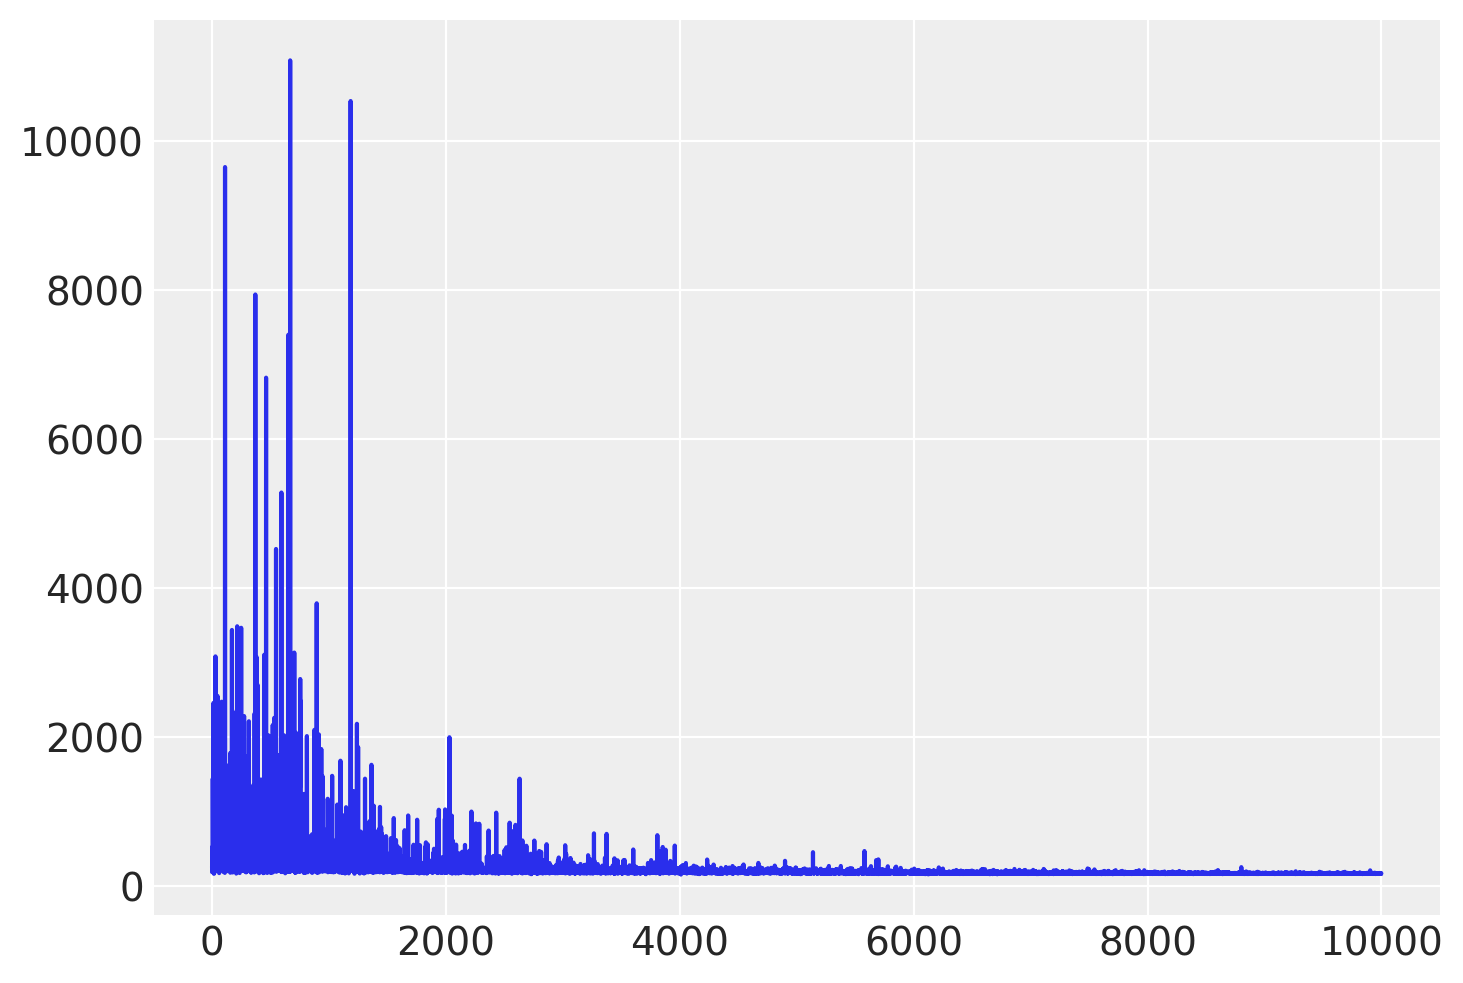

In [5]:
plt.plot(mean_field.hist);  # loss function: -ELBO

In [6]:
approx_sample = mean_field.sample(1000)

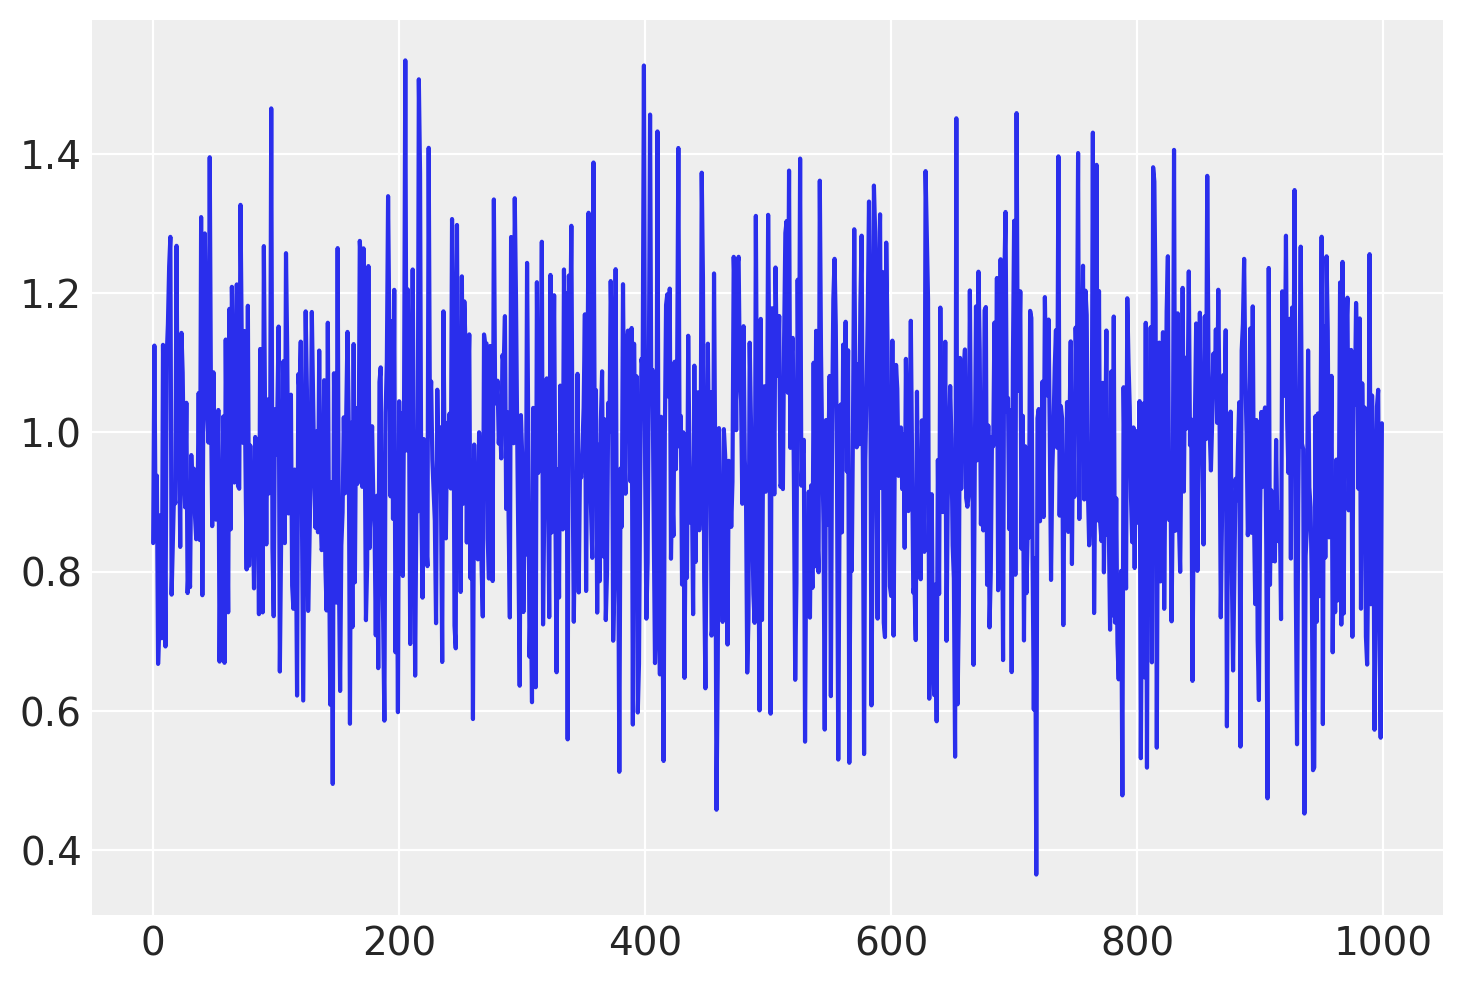

In [7]:
alpha = approx_sample.posterior["alpha"].values.flatten()
plt.plot(alpha)

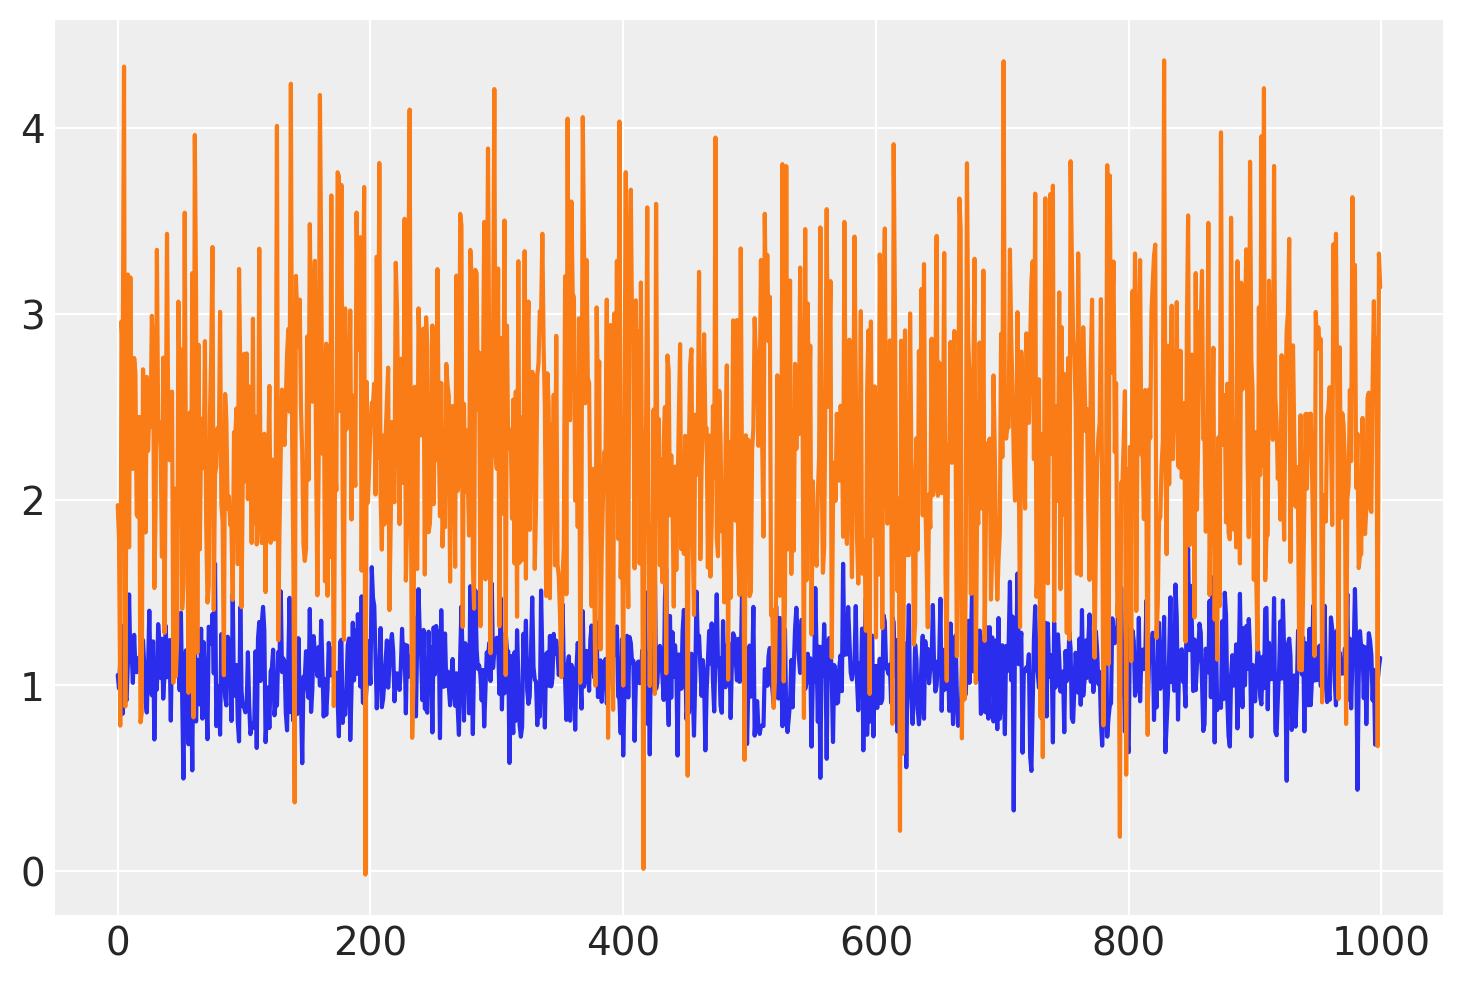

In [8]:
beta = approx_sample.posterior["beta"].values
plt.plot(beta[0,:])

#### Demonstration in Logistic (Binomial) Regression

In [11]:
# true params
beta0_true = 0.7
beta1_true = 0.4
# number of yes/no questions
n = 20

sample_size = 30
x = np.linspace(-10, 20, sample_size)
# Linear model
mu_true = beta0_true + beta1_true * x
# transformation (inverse logit function = expit)
p_true = expit(mu_true)
# Generate data
y = np.random.binomial(n, p_true)
# bundle data into dataframe
data = pd.DataFrame({"x": x, "y": y})

In [12]:
data.head()

,x,y
0,-10.000000,0
1,-8.965517,2
2,-7.931034,1
3,-6.896552,3
4,-5.862069,2


### Activity 2

Do the same with logistic regression. In order to incorporate a deterministic function in the `PyMC` model definition, you can use the function below (for the sigmoid function):

`p = pm.Deterministic("p", pm.math.invlogit(mu))`

Also, the Bernoulli likelihood can be specified with the code below (with n, p and observed to be provided by the user):

`pm.Binomial("y", n=..., p=..., observed= ...)`

## Data-generating process (Binomial logistic regression)
For $i = 1, \ldots, m$, let $x_i$ be fixed design points and define
$$
\mu_i = \beta_0 + \beta_1 x_i,
\qquad
p_i = \operatorname{logit}^{-1}(\mu_i)
= \frac{1}{1 + \exp(-\mu_i)}.
$$

Conditional on $(\beta_0,\beta_1)$, the responses follow
$$
y_i \mid \beta_0,\beta_1 \sim \operatorname{Binomial}(n,p_i),
\qquad i = 1,\ldots,m.
$$

We place independent Gaussian priors on the regression coefficients:
$$
\beta_0 \sim \mathcal{N}(0,10^2),
\qquad
\beta_1 \sim \mathcal{N}(0,10^2).
$$

Hence the likelihood is
$$
p(\mathbf{y} \mid \beta_0,\beta_1,\mathbf{x})
=
\prod_{i=1}^{m}
\binom{n}{y_i}
p_i^{y_i}(1-p_i)^{n-y_i},
$$
where
$$
p_i = \operatorname{logit}^{-1}(\beta_0+\beta_1 x_i).
$$

In [ ]:
with pm.Model() as logistic_regression_model:
    x = pm.Data("x", data["x"])
    # priors
    beta0 = pm.Normal("beta0", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    # regressions
    mu = beta0 + beta1 * x
    # sigmoid
    p = pm.Deterministic("p", pm.math.invlogit(mu))
    # likelihood
    pm.Binomial("y", n=n, p=p, observed=data["y"])

In [14]:
#coords = {"observation": data.index.values}

#with pm.Model() as logistic_regression_model:
    # priors
#    x = pm.Data("x", data["x"], dims="observation")
#    beta0 = pm.Normal("beta0", mu=0, sigma=1)
#    beta1 = pm.Normal("beta1", mu=0, sigma=1)
#    # linear model
##    mu = beta0 + beta1 * x
#    p = pm.Deterministic("p", pm.math.invlogit(mu), dims="observation")
#    # likelihood
#    pm.Binomial("y", n=n, p=p, observed=data["y"], dims="observation")

In [15]:
with logistic_regression_model:
    mean_field = pm.fit()

C:\Users\13287\anaconda3\envs\gpflow310\lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 48.731


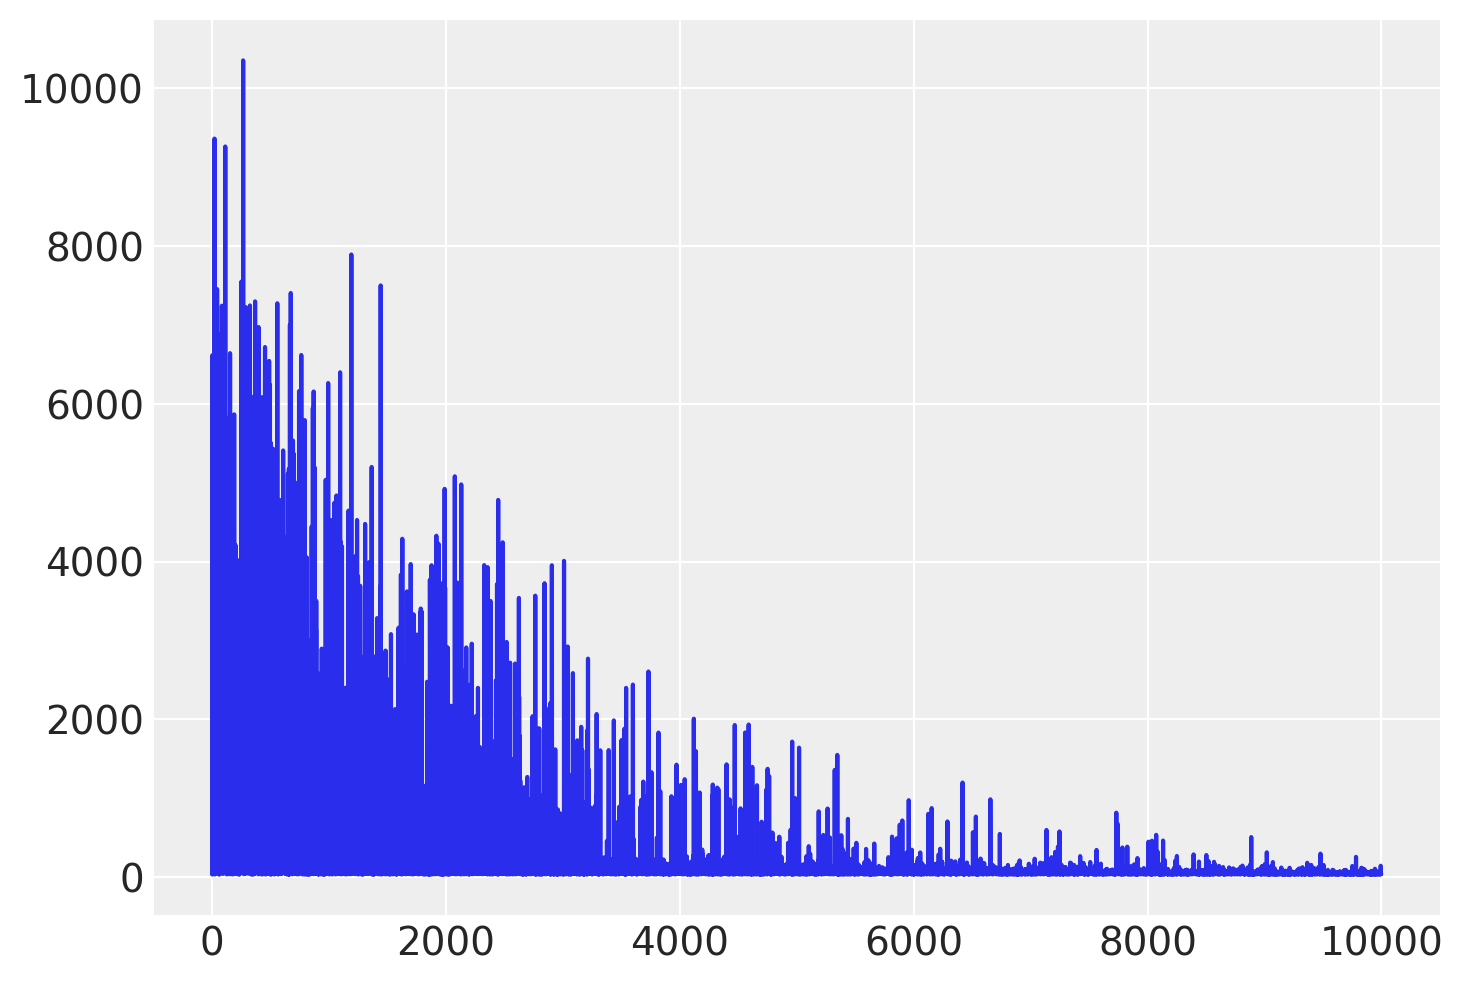

In [16]:
plt.plot(mean_field.hist)
approx_sample = mean_field.sample(1000)

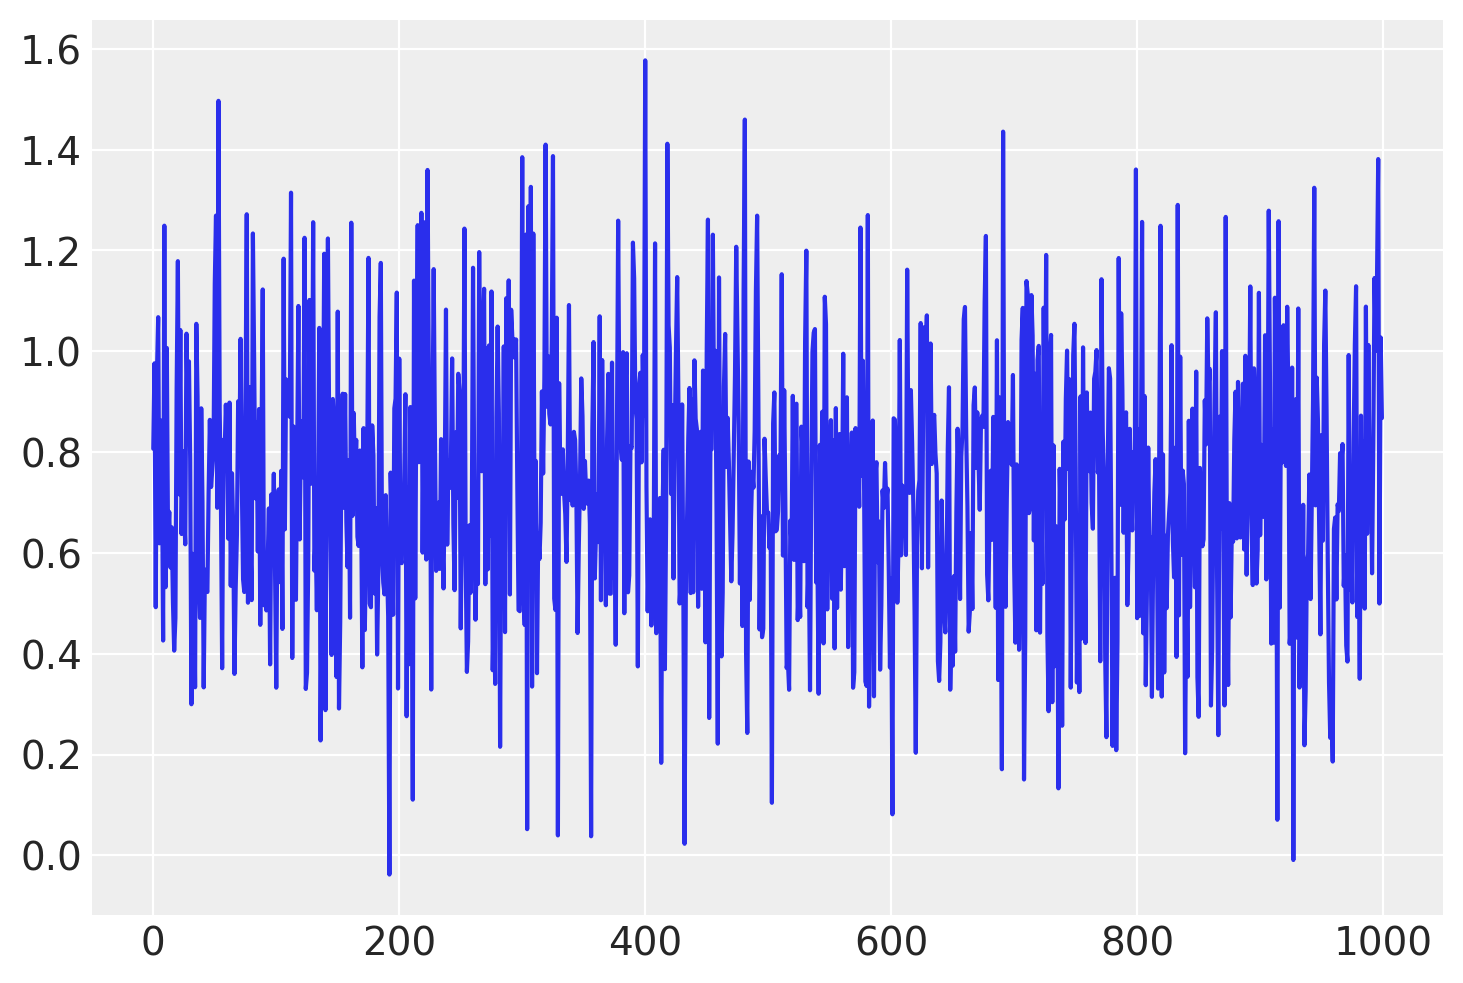

In [17]:
beta0 = approx_sample.posterior["beta0"].values.flatten()
plt.plot(beta0)

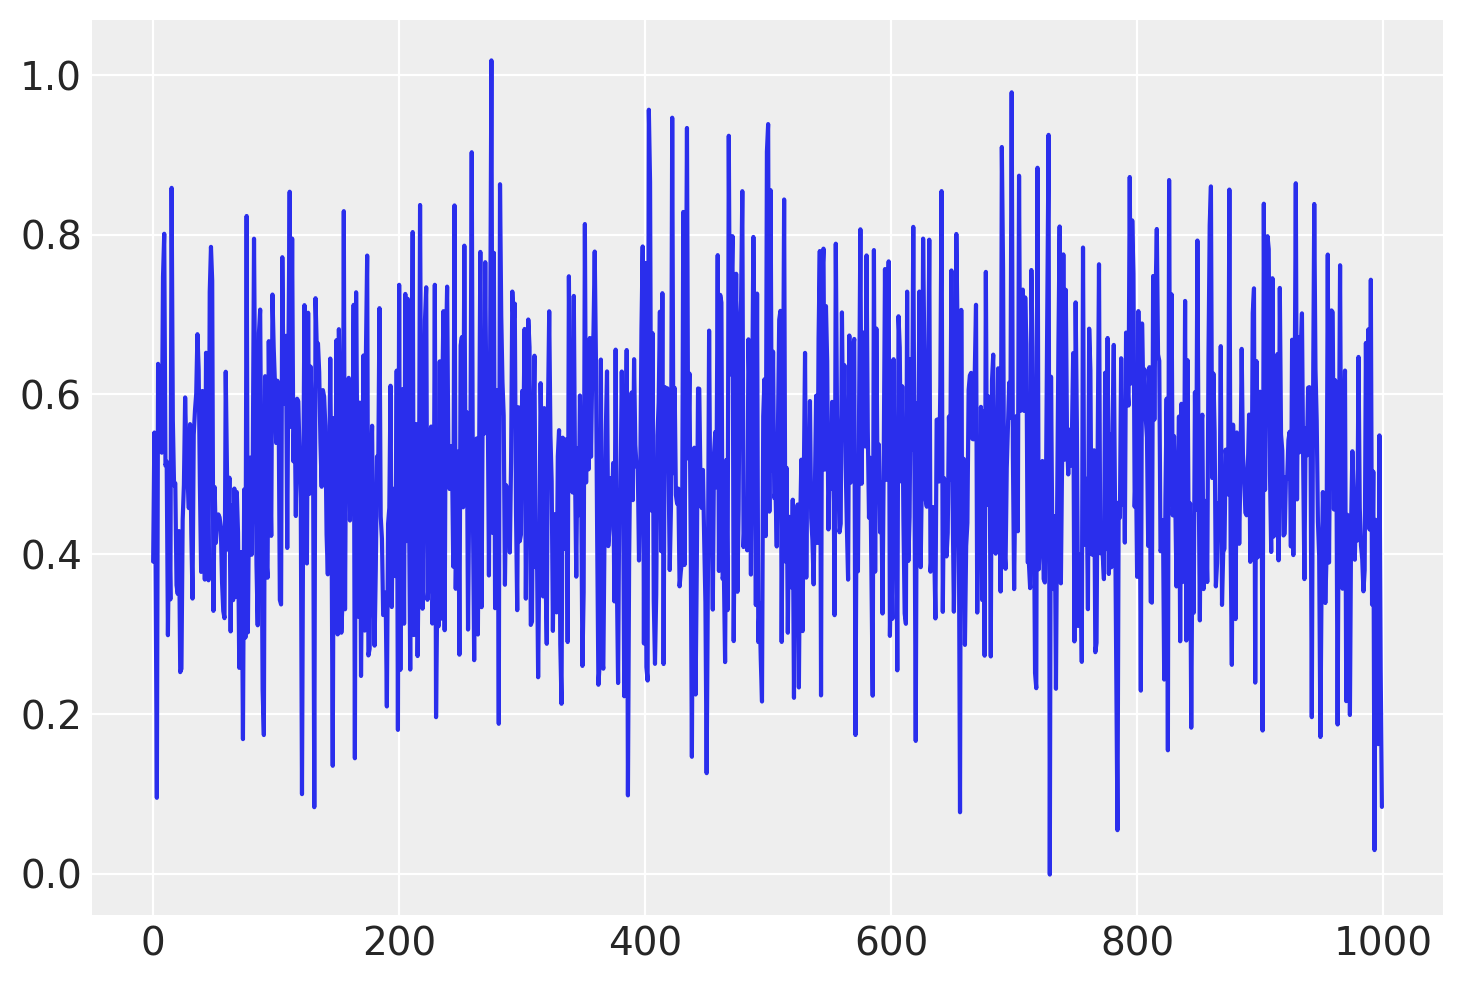

In [18]:
beta1 = approx_sample.posterior["beta1"].values.flatten()
plt.plot(beta1)